In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
df = pd.read_csv('./feynmantest/MLPKAN_speedtestnodelayer.csv')

In [15]:
print(df.head())

   Layers  Nodes Function  train MSE  test MSE      time
0       1      4   I.12.1   0.001142  0.001024  1.006190
1       1      4   I.12.4   0.000029  0.000031  4.217771
2       1      4   I.12.5   0.001104  0.001028  0.670524
3       1      4   I.14.3   0.000388  0.000353  1.841988
4       1      4   I.14.4   0.000099  0.000081  0.377879


In [16]:

# Group by Layers and Nodes, then calculate median test MSE
mean_mse = df.groupby(['Layers', 'Nodes'])['test MSE'].mean().reset_index()

# Create pivot table with Layers as columns and Nodes as rows
pivot_table = mean_mse.pivot(index='Nodes', columns='Layers', values='test MSE')

# Display the table
print("Mean Test MSE by Nodes (Y-axis) and Layers (X-axis):")
print(pivot_table)

Mean Test MSE by Nodes (Y-axis) and Layers (X-axis):
Layers         1         2         3         4         5
Nodes                                                   
4       0.002672  0.002292  0.001795  0.002468  0.002295
8       0.002606  0.002016  0.001538  0.001406  0.001846
16      0.002131  0.002115  0.001674  0.001061  0.002086
32      0.002442  0.002023  0.002185  0.001872  0.002354
64      0.002536  0.002112  0.001389  0.002565  0.002819
128     0.002539  0.008375  0.006914  0.007218  0.005986


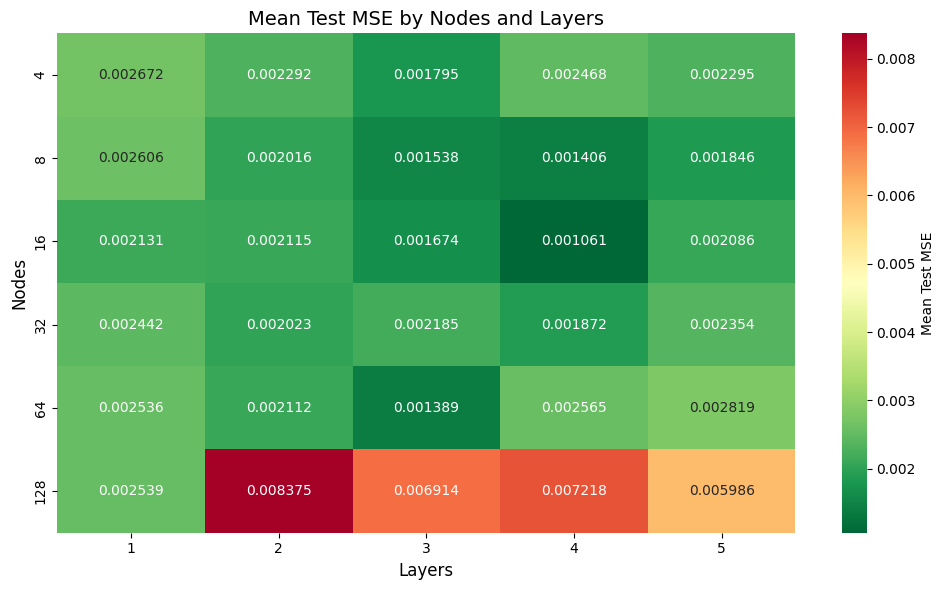

In [17]:
# Create heatmap
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt='.6f', cmap='RdYlGn_r', cbar_kws={'label': 'Mean Test MSE'}, ax=ax)
ax.set_xlabel('Layers', fontsize=12)
ax.set_ylabel('Nodes', fontsize=12)
ax.set_title('Mean Test MSE by Nodes and Layers', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
mean_time = df.groupby(['Layers', 'Nodes'])['time'].mean().reset_index()

pivot_time = mean_time.pivot(index='Nodes', columns='Layers', values='time')

print("Mean Time by Nodes (Y-axis) and Layers (X-axis):")
print(pivot_time)


Mean Time by Nodes (Y-axis) and Layers (X-axis):
Layers         1          2          3          4          5
Nodes                                                       
4       1.702259   1.290178   1.176589   1.355904   1.531498
8       1.932426   1.406429   1.151525   1.379777   1.451911
16      1.755618   1.039301   1.453649   1.512282   1.697595
32      2.130791   1.414758   1.343695   1.835288   2.419017
64      2.172206   2.036895   2.364515   3.780156   4.914112
128     3.359729  11.499790  26.906642  19.299103  23.402200


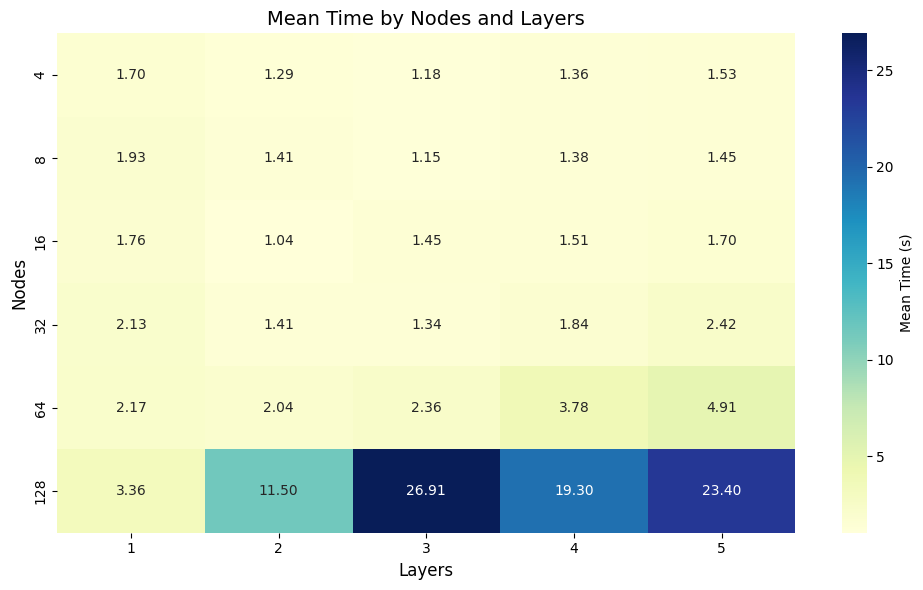

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_time, annot=True, fmt='.2f', cmap='YlGnBu', cbar_kws={'label': 'Mean Time (s)'}, ax=ax)
ax.set_xlabel('Layers', fontsize=12)
ax.set_ylabel('Nodes', fontsize=12)
ax.set_title('Mean Time by Nodes and Layers', fontsize=14)
plt.tight_layout()
plt.show()

